# FedTwin-Air: Federated Learning Experiment (Manual FedAvg)
### Federated Learning Enabled Digital Twin Framework for Urban Air Quality Management — East African Cities

This notebook builds the federated version of the model in Google Colab,
using manual FedAvg (TensorFlow Federated is not installed - confirmed
incompatible with the current Python version on both Kaggle and Colab).

**Plan:**
1. Rebuild the standard LSTM pipeline
2. Build real per-city federated clients
3. Implement manual FedAvg and run the federated training loop


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import glob

# Search Drive for the zip file
zip_paths = glob.glob('/content/drive/MyDrive/**/*air_quality_and_weather*.zip', recursive=True)
print("Zip file(s) found:", zip_paths)

Mounted at /content/drive
Zip file(s) found: ['/content/drive/MyDrive/_air_quality_and_weather east affrican countries.zip']


## Extract and load the dataset

In [2]:
import zipfile
import os
import pandas as pd
import numpy as np

zip_path = '/content/drive/MyDrive/_air_quality_and_weather east affrican countries.zip'
EXTRACT_DIR = '/content/air_quality_data'
os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(EXTRACT_DIR)

csv_paths = sorted(glob.glob(f"{EXTRACT_DIR}/*_air_quality_and_weather.csv"))
print(f"Found {len(csv_paths)} CSV files")

dfs = []
for path in csv_paths:
    df = pd.read_csv(path, parse_dates=["date"])
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
print("Combined shape:", data.shape)
print("Cities:", data['city'].unique())

Found 7 CSV files
Combined shape: (9086, 23)
Cities: ['AddisAbaba_Ethiopia' 'DarEsSalaam_Tanzania' 'Dodoma_Tanzania'
 'Kampala_Uganda' 'Kigali_Rwanda' 'Mogadishu_Somalia' 'Nairobi_Kenya']


## Clean data and set up variables

In [3]:
data = data[data['date'] > '2022-08-04'].reset_index(drop=True)
data = data.sort_values(['city', 'date']).reset_index(drop=True)

SEQUENCE_LENGTH = 120
FEATURE_COLUMNS = [
    "pm2_5", "temperature_2m_mean", "relative_humidity_2m_mean",
    "wind_speed_10m_mean", "precipitation_sum",
    "surface_pressure_mean", "shortwave_radiation_sum",
]
TARGET_COLUMN = "pm2_5"
N_FEATURES = len(FEATURE_COLUMNS)
target_col_idx = FEATURE_COLUMNS.index(TARGET_COLUMN)

print("Rows after cleaning:", data.shape[0])
print("Missing values:", data.isna().sum().sum())
print("Features:", FEATURE_COLUMNS)

Rows after cleaning: 9058
Missing values: 0
Features: ['pm2_5', 'temperature_2m_mean', 'relative_humidity_2m_mean', 'wind_speed_10m_mean', 'precipitation_sum', 'surface_pressure_mean', 'shortwave_radiation_sum']


## Build real per-city federated clients

Each city gets its own independently-fit scaler and its own windowed
train/test data, built only from that city's own history. This is what
makes this genuinely federated - unlike the centralized version, no city's
data influences another city's scaling or windows.

In [4]:
from sklearn.preprocessing import MinMaxScaler
import math

def fill_missing(df):
    df[FEATURE_COLUMNS] = df[FEATURE_COLUMNS].ffill().bfill()
    return df

def make_windows(values_2d, seq_len, target_col_idx=0):
    X, y = [], []
    for i in range(seq_len, len(values_2d)):
        X.append(values_2d[i - seq_len:i, :])
        y.append(values_2d[i, target_col_idx])
    return np.array(X), np.array(y)

def build_city_client(df, seq_len=SEQUENCE_LENGTH, train_frac=0.8):
    df = fill_missing(df.copy())
    values = df[FEATURE_COLUMNS].values
    n = len(df)
    train_len = math.ceil(n * train_frac)

    scaler_city = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler_city.fit_transform(values[:train_len])
    test_scaled = scaler_city.transform(values[train_len - seq_len:])

    x_tr, y_tr = make_windows(train_scaled, seq_len, target_col_idx)
    x_te, y_te = make_windows(test_scaled, seq_len, target_col_idx)

    return {
        "x_train": x_tr.astype(np.float32),
        "y_train": y_tr.reshape(-1, 1).astype(np.float32),
        "x_test": x_te.astype(np.float32),
        "y_test": y_te.reshape(-1, 1).astype(np.float32),
        "scaler": scaler_city,
    }

city_clients = {}
for city in data['city'].unique():
    city_df = data[data['city'] == city].copy()
    city_clients[city] = build_city_client(city_df)

for city, c in city_clients.items():
    print(f"{city}: x_train {c['x_train'].shape}, x_test {c['x_test'].shape}")

AddisAbaba_Ethiopia: x_train (916, 120, 7), x_test (258, 120, 7)
DarEsSalaam_Tanzania: x_train (916, 120, 7), x_test (258, 120, 7)
Dodoma_Tanzania: x_train (916, 120, 7), x_test (258, 120, 7)
Kampala_Uganda: x_train (916, 120, 7), x_test (258, 120, 7)
Kigali_Rwanda: x_train (916, 120, 7), x_test (258, 120, 7)
Mogadishu_Somalia: x_train (916, 120, 7), x_test (258, 120, 7)
Nairobi_Kenya: x_train (916, 120, 7), x_test (258, 120, 7)


## Model architecture and FedAvg helper functions

Standard LSTM (same as the centralized baseline). Two helper functions:
one to get/set a model's weights, and one to average multiple cities'
weights together, weighted by how much training data each city has.

In [5]:
import tensorflow as tf
from tensorflow.keras import layers

def build_lstm_model(sequence_length=SEQUENCE_LENGTH, n_features=N_FEATURES, units=64):
    model = tf.keras.Sequential([
        layers.Input(shape=(sequence_length, n_features)),
        layers.LSTM(units, return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(units // 2),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='linear')
    ])
    return model

def get_model_weights(model):
    return model.get_weights()

def set_model_weights(model, weights):
    model.set_weights(weights)

def weighted_average_weights(client_weights_list, client_sample_counts):
    total_samples = sum(client_sample_counts)
    n_layers = len(client_weights_list[0])
    averaged_weights = []
    for layer_idx in range(n_layers):
        layer_sum = np.zeros_like(client_weights_list[0][layer_idx])
        for city_weights, n_samples in zip(client_weights_list, client_sample_counts):
            layer_sum += city_weights[layer_idx] * (n_samples / total_samples)
        averaged_weights.append(layer_sum)
    return averaged_weights

client_ids = list(city_clients.keys())
client_sample_counts = [city_clients[c]['x_train'].shape[0] for c in client_ids]

# Build each city's local model ONCE, reused every round (avoids rebuild overhead)
local_models = {}
for city in client_ids:
    m = build_lstm_model(units=64)
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    local_models[city] = m

print("Client IDs:", client_ids)
print("Sample counts:", client_sample_counts)
print("Local models built for all clients.")

Client IDs: ['AddisAbaba_Ethiopia', 'DarEsSalaam_Tanzania', 'Dodoma_Tanzania', 'Kampala_Uganda', 'Kigali_Rwanda', 'Mogadishu_Somalia', 'Nairobi_Kenya']
Sample counts: [916, 916, 916, 916, 916, 916, 916]
Local models built for all clients.


## FedAvg training loop

Starting with a shorter run (30 rounds, 1 local epoch each) to check the
trend before committing to a longer run. Each round: every city trains
locally starting from the current global weights, then all cities'
updated weights are averaged into the new global model.

In [6]:
GLOBAL_ROUNDS = 30
LOCAL_EPOCHS = 1

global_model = build_lstm_model(units=64)
global_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
global_weights = get_model_weights(global_model)

round_val_losses = []

for round_num in range(GLOBAL_ROUNDS):
    client_weights_list = []

    for city in client_ids:
        c = city_clients[city]
        local_model = local_models[city]
        set_model_weights(local_model, global_weights)

        local_model.fit(c["x_train"], c["y_train"], epochs=LOCAL_EPOCHS, batch_size=32, verbose=0)

        client_weights_list.append(get_model_weights(local_model))

    global_weights = weighted_average_weights(client_weights_list, client_sample_counts)
    set_model_weights(global_model, global_weights)

    # Evaluate on pooled test data (all cities' test sets concatenated) for a quick per-round check
    all_x_test = np.concatenate([city_clients[c]["x_test"] for c in client_ids], axis=0)
    all_y_test = np.concatenate([city_clients[c]["y_test"] for c in client_ids], axis=0)
    val_loss = global_model.evaluate(all_x_test, all_y_test, verbose=0)

    round_val_losses.append(val_loss[0])
    print(f"Round {round_num + 1}/{GLOBAL_ROUNDS} - val_loss: {val_loss[0]:.4f}, val_mae: {val_loss[1]:.4f}")

Round 1/30 - val_loss: 0.0242, val_mae: 0.1208
Round 2/30 - val_loss: 0.0190, val_mae: 0.1071
Round 3/30 - val_loss: 0.0165, val_mae: 0.0931
Round 4/30 - val_loss: 0.0149, val_mae: 0.0899
Round 5/30 - val_loss: 0.0140, val_mae: 0.0888
Round 6/30 - val_loss: 0.0136, val_mae: 0.0869
Round 7/30 - val_loss: 0.0136, val_mae: 0.0868
Round 8/30 - val_loss: 0.0133, val_mae: 0.0865
Round 9/30 - val_loss: 0.0135, val_mae: 0.0852
Round 10/30 - val_loss: 0.0131, val_mae: 0.0851
Round 11/30 - val_loss: 0.0129, val_mae: 0.0848
Round 12/30 - val_loss: 0.0131, val_mae: 0.0843
Round 13/30 - val_loss: 0.0126, val_mae: 0.0843
Round 14/30 - val_loss: 0.0131, val_mae: 0.0834
Round 15/30 - val_loss: 0.0123, val_mae: 0.0823
Round 16/30 - val_loss: 0.0123, val_mae: 0.0822
Round 17/30 - val_loss: 0.0121, val_mae: 0.0815
Round 18/30 - val_loss: 0.0119, val_mae: 0.0807
Round 19/30 - val_loss: 0.0117, val_mae: 0.0799
Round 20/30 - val_loss: 0.0117, val_mae: 0.0802
Round 21/30 - val_loss: 0.0115, val_mae: 0.0791
R

## Evaluate the federated model per city

Since each city has its own scaler, evaluation must be done per city,
not on the pooled scaled values used for the quick per-round check above.

In [7]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def inverse_transform_target(y_scaled, scaler, target_col_idx, n_features):
    dummy = np.zeros((len(y_scaled), n_features))
    dummy[:, target_col_idx] = y_scaled.flatten()
    return scaler.inverse_transform(dummy)[:, target_col_idx]

results_per_city = {}
for city in client_ids:
    c = city_clients[city]
    y_pred_scaled = global_model.predict(c["x_test"], verbose=0)

    y_pred = inverse_transform_target(y_pred_scaled, c["scaler"], target_col_idx, N_FEATURES)
    y_true = inverse_transform_target(c["y_test"], c["scaler"], target_col_idx, N_FEATURES)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    results_per_city[city] = {"rmse": rmse, "mae": mae, "r2": r2}
    print(f"{city}: RMSE={rmse:.3f}, MAE={mae:.3f}, R2={r2:.3f}")

avg_rmse = np.mean([v["rmse"] for v in results_per_city.values()])
avg_mae = np.mean([v["mae"] for v in results_per_city.values()])
avg_r2 = np.mean([v["r2"] for v in results_per_city.values()])
print(f"\nAverage across cities: RMSE={avg_rmse:.3f}, MAE={avg_mae:.3f}, R2={avg_r2:.3f}")

AddisAbaba_Ethiopia: RMSE=4.459, MAE=3.351, R2=0.407
DarEsSalaam_Tanzania: RMSE=1.942, MAE=1.625, R2=0.351
Dodoma_Tanzania: RMSE=2.864, MAE=2.227, R2=0.479
Kampala_Uganda: RMSE=6.766, MAE=5.329, R2=0.089
Kigali_Rwanda: RMSE=6.814, MAE=5.073, R2=0.439
Mogadishu_Somalia: RMSE=1.799, MAE=1.291, R2=0.399
Nairobi_Kenya: RMSE=4.469, MAE=3.407, R2=0.669

Average across cities: RMSE=4.159, MAE=3.186, R2=0.405


In [8]:
import pickle

GLOBAL_ROUNDS = 300
LOCAL_EPOCHS = 1
CHECKPOINT_EVERY = 50
CHECKPOINT_DIR = '/content/drive/MyDrive/fedtwinair_checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

global_model = build_lstm_model(units=64)
global_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
global_weights = get_model_weights(global_model)

round_val_losses = []

all_x_test = np.concatenate([city_clients[c]["x_test"] for c in client_ids], axis=0)
all_y_test = np.concatenate([city_clients[c]["y_test"] for c in client_ids], axis=0)

for round_num in range(GLOBAL_ROUNDS):
    client_weights_list = []

    for city in client_ids:
        c = city_clients[city]
        local_model = local_models[city]
        set_model_weights(local_model, global_weights)
        local_model.fit(c["x_train"], c["y_train"], epochs=LOCAL_EPOCHS, batch_size=32, verbose=0)
        client_weights_list.append(get_model_weights(local_model))

    global_weights = weighted_average_weights(client_weights_list, client_sample_counts)
    set_model_weights(global_model, global_weights)

    val_loss = global_model.evaluate(all_x_test, all_y_test, verbose=0)
    round_val_losses.append(val_loss[0])

    if (round_num + 1) % 10 == 0:
        print(f"Round {round_num + 1}/{GLOBAL_ROUNDS} - val_loss: {val_loss[0]:.4f}, val_mae: {val_loss[1]:.4f}")

    if (round_num + 1) % CHECKPOINT_EVERY == 0:
        with open(f"{CHECKPOINT_DIR}/weights_round_{round_num + 1}.pkl", 'wb') as f:
            pickle.dump(global_weights, f)
        print(f"  -> Checkpoint saved at round {round_num + 1}")

print("\nTraining complete.")

Round 10/300 - val_loss: 0.0135, val_mae: 0.0849
Round 20/300 - val_loss: 0.0116, val_mae: 0.0822
Round 30/300 - val_loss: 0.0102, val_mae: 0.0759
Round 40/300 - val_loss: 0.0088, val_mae: 0.0697
Round 50/300 - val_loss: 0.0080, val_mae: 0.0672
  -> Checkpoint saved at round 50
Round 60/300 - val_loss: 0.0079, val_mae: 0.0652
Round 70/300 - val_loss: 0.0078, val_mae: 0.0658
Round 80/300 - val_loss: 0.0078, val_mae: 0.0644
Round 90/300 - val_loss: 0.0076, val_mae: 0.0651
Round 100/300 - val_loss: 0.0075, val_mae: 0.0635
  -> Checkpoint saved at round 100
Round 110/300 - val_loss: 0.0076, val_mae: 0.0637
Round 120/300 - val_loss: 0.0075, val_mae: 0.0637
Round 130/300 - val_loss: 0.0074, val_mae: 0.0631
Round 140/300 - val_loss: 0.0074, val_mae: 0.0643
Round 150/300 - val_loss: 0.0074, val_mae: 0.0635
  -> Checkpoint saved at round 150
Round 160/300 - val_loss: 0.0074, val_mae: 0.0632
Round 170/300 - val_loss: 0.0073, val_mae: 0.0639
Round 180/300 - val_loss: 0.0074, val_mae: 0.0635
Round

## Evaluate the final federated model (after 300 rounds) per city

In [9]:
results_per_city = {}
for city in client_ids:
    c = city_clients[city]
    y_pred_scaled = global_model.predict(c["x_test"], verbose=0)

    y_pred = inverse_transform_target(y_pred_scaled, c["scaler"], target_col_idx, N_FEATURES)
    y_true = inverse_transform_target(c["y_test"], c["scaler"], target_col_idx, N_FEATURES)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    results_per_city[city] = {"rmse": rmse, "mae": mae, "r2": r2}
    print(f"{city}: RMSE={rmse:.3f}, MAE={mae:.3f}, R2={r2:.3f}")

avg_rmse = np.mean([v["rmse"] for v in results_per_city.values()])
avg_mae = np.mean([v["mae"] for v in results_per_city.values()])
avg_r2 = np.mean([v["r2"] for v in results_per_city.values()])
print(f"\nAverage across cities: RMSE={avg_rmse:.3f}, MAE={avg_mae:.3f}, R2={avg_r2:.3f}")

AddisAbaba_Ethiopia: RMSE=4.033, MAE=3.042, R2=0.515
DarEsSalaam_Tanzania: RMSE=1.733, MAE=1.431, R2=0.483
Dodoma_Tanzania: RMSE=2.467, MAE=2.003, R2=0.614
Kampala_Uganda: RMSE=6.526, MAE=5.165, R2=0.152
Kigali_Rwanda: RMSE=5.460, MAE=4.007, R2=0.640
Mogadishu_Somalia: RMSE=1.488, MAE=1.087, R2=0.589
Nairobi_Kenya: RMSE=3.895, MAE=2.913, R2=0.748

Average across cities: RMSE=3.657, MAE=2.807, R2=0.534


## Loss vs. Round (federated training curve)

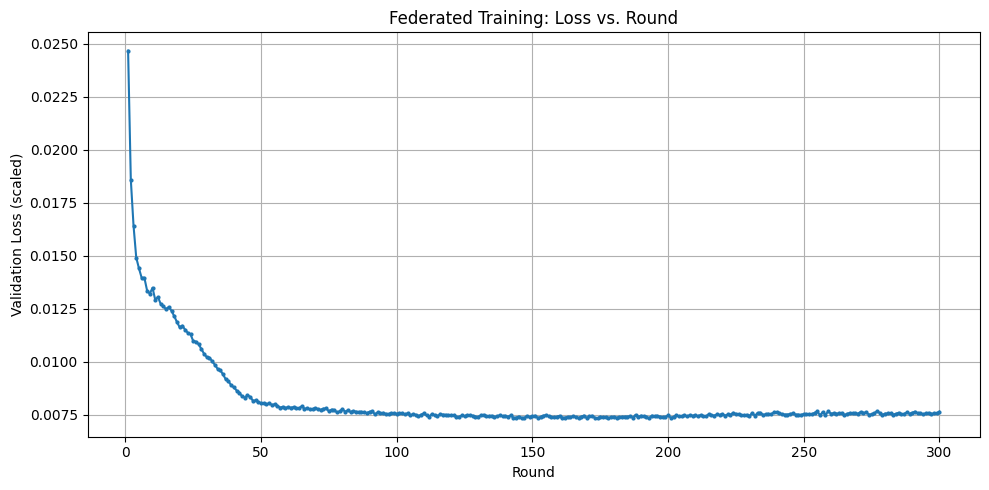

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, GLOBAL_ROUNDS + 1), round_val_losses, marker='o', markersize=2, linestyle='-')
plt.xlabel('Round')
plt.ylabel('Validation Loss (scaled)')
plt.title('Federated Training: Loss vs. Round')
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fedtwinair_loss_vs_round.png', dpi=150)
plt.show()

## Predicted vs. Actual PM2.5 (federated model, one city)

Showing this for Nairobi, since it had the strongest federated result
(R2 = 0.743), making for a clear, representative visual.

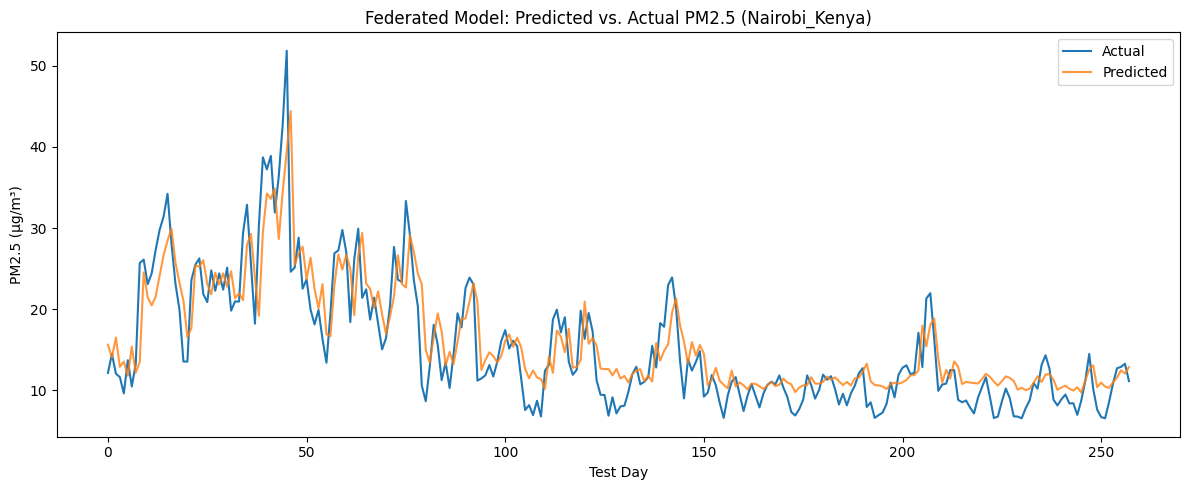

In [11]:
city_to_plot = "Nairobi_Kenya"
c = city_clients[city_to_plot]

y_pred_scaled = global_model.predict(c["x_test"], verbose=0)
y_pred = inverse_transform_target(y_pred_scaled, c["scaler"], target_col_idx, N_FEATURES)
y_true = inverse_transform_target(c["y_test"], c["scaler"], target_col_idx, N_FEATURES)

plt.figure(figsize=(12, 5))
plt.plot(y_true, label='Actual', linewidth=1.5)
plt.plot(y_pred, label='Predicted', linewidth=1.5, alpha=0.8)
plt.xlabel('Test Day')
plt.ylabel('PM2.5 (µg/m³)')
plt.title(f'Federated Model: Predicted vs. Actual PM2.5 ({city_to_plot})')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fedtwinair_pred_vs_actual.png', dpi=150)
plt.show()

## Predicted vs. Actual PM2.5, all 7 cities

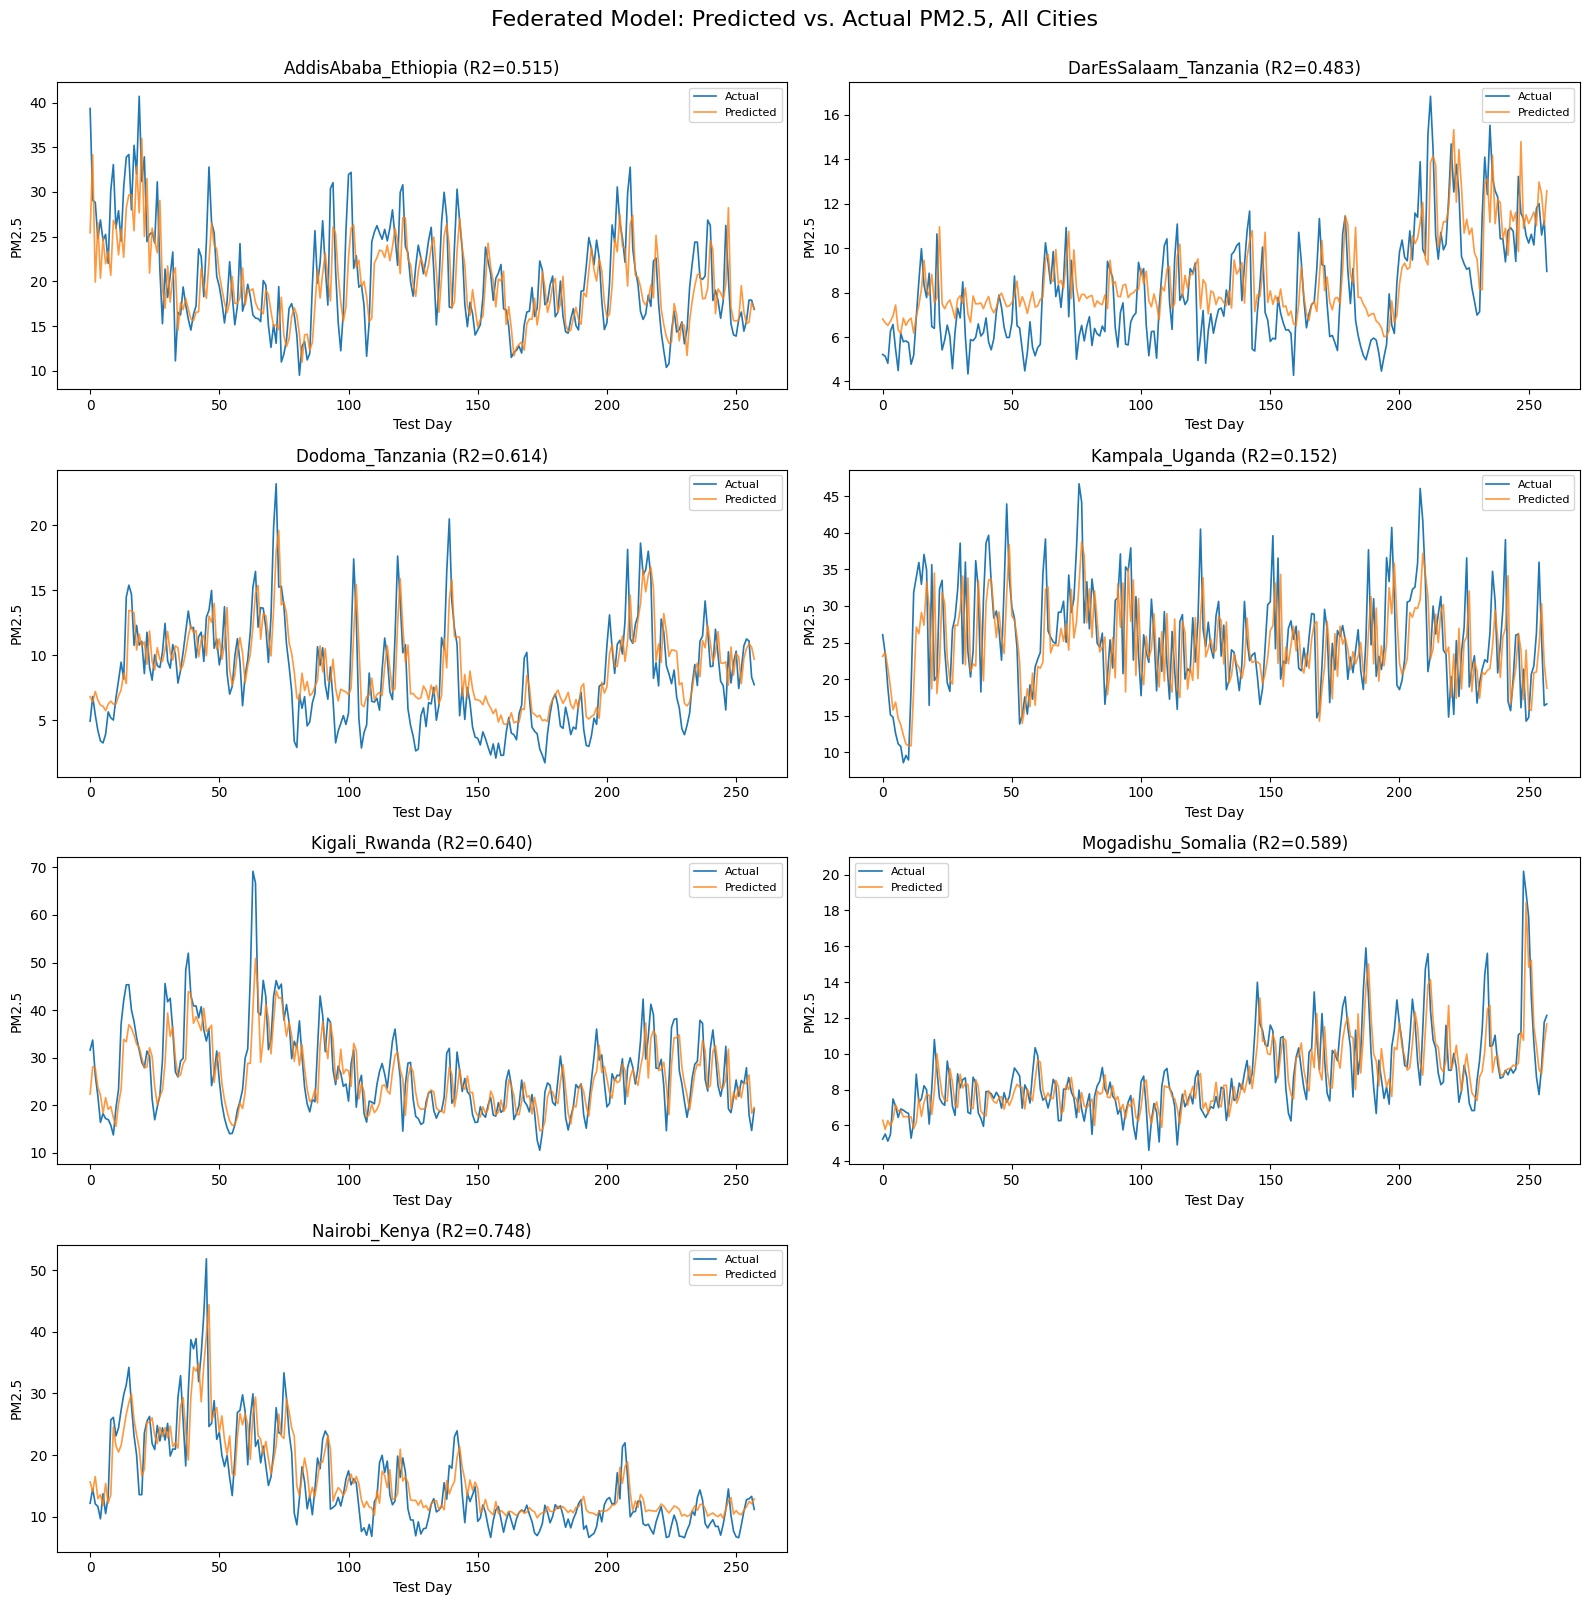

In [12]:
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

for i, city in enumerate(client_ids):
    c = city_clients[city]
    y_pred_scaled = global_model.predict(c["x_test"], verbose=0)
    y_pred = inverse_transform_target(y_pred_scaled, c["scaler"], target_col_idx, N_FEATURES)
    y_true = inverse_transform_target(c["y_test"], c["scaler"], target_col_idx, N_FEATURES)

    axes[i].plot(y_true, label='Actual', linewidth=1.2)
    axes[i].plot(y_pred, label='Predicted', linewidth=1.2, alpha=0.8)
    axes[i].set_title(f"{city} (R2={results_per_city[city]['r2']:.3f})")
    axes[i].set_xlabel('Test Day')
    axes[i].set_ylabel('PM2.5')
    axes[i].legend(fontsize=8)

fig.delaxes(axes[7])  # only 7 cities, remove the 8th empty subplot
plt.suptitle('Federated Model: Predicted vs. Actual PM2.5, All Cities', fontsize=16, y=1.00)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fedtwinair_pred_vs_actual_all_cities.png', dpi=150, bbox_inches='tight')
plt.show()

## GRU model

Same architecture shape as the LSTM version, just swapping GRU layers in
place of LSTM layers - a simpler, faster cell type. Everything else
(federated clients, FedAvg loop, evaluation) stays the same for a fair
comparison.

In [13]:
def build_gru_model(sequence_length=SEQUENCE_LENGTH, n_features=N_FEATURES, units=64):
    model = tf.keras.Sequential([
        layers.Input(shape=(sequence_length, n_features)),
        layers.GRU(units, return_sequences=True),
        layers.Dropout(0.2),
        layers.GRU(units // 2),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='linear')
    ])
    return model

test_model = build_gru_model(units=64)
test_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
test_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 120, 64)        │        14,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 120, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,513 (95.75 KB)

 Trainable params: 24,513 (95.75 KB)

 Non-trainable params: 0 (0.00 B)

## Full FedAvg run with GRU: 300 rounds, 1 local epoch

Same setup as the LSTM federated run, just with GRU models. Reusing the
same client data (city_clients) - only the model architecture changes.

In [14]:
# Build fresh per-city local models using GRU this time
local_models_gru = {}
for city in client_ids:
    m = build_gru_model(units=64)
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    local_models_gru[city] = m

GLOBAL_ROUNDS = 300
LOCAL_EPOCHS = 1
CHECKPOINT_EVERY = 50
CHECKPOINT_DIR_GRU = '/content/drive/MyDrive/fedtwinair_checkpoints_gru'
os.makedirs(CHECKPOINT_DIR_GRU, exist_ok=True)

global_model_gru = build_gru_model(units=64)
global_model_gru.compile(optimizer='adam', loss='mse', metrics=['mae'])
global_weights_gru = get_model_weights(global_model_gru)

round_val_losses_gru = []

for round_num in range(GLOBAL_ROUNDS):
    client_weights_list = []

    for city in client_ids:
        c = city_clients[city]
        local_model = local_models_gru[city]
        set_model_weights(local_model, global_weights_gru)
        local_model.fit(c["x_train"], c["y_train"], epochs=LOCAL_EPOCHS, batch_size=32, verbose=0)
        client_weights_list.append(get_model_weights(local_model))

    global_weights_gru = weighted_average_weights(client_weights_list, client_sample_counts)
    set_model_weights(global_model_gru, global_weights_gru)

    val_loss = global_model_gru.evaluate(all_x_test, all_y_test, verbose=0)
    round_val_losses_gru.append(val_loss[0])

    if (round_num + 1) % 10 == 0:
        print(f"Round {round_num + 1}/{GLOBAL_ROUNDS} - val_loss: {val_loss[0]:.4f}, val_mae: {val_loss[1]:.4f}")

    if (round_num + 1) % CHECKPOINT_EVERY == 0:
        with open(f"{CHECKPOINT_DIR_GRU}/weights_round_{round_num + 1}.pkl", 'wb') as f:
            pickle.dump(global_weights_gru, f)
        print(f"  -> Checkpoint saved at round {round_num + 1}")

print("\nGRU training complete.")

Round 10/300 - val_loss: 0.0108, val_mae: 0.0754
Round 20/300 - val_loss: 0.0086, val_mae: 0.0682
Round 30/300 - val_loss: 0.0084, val_mae: 0.0659
Round 40/300 - val_loss: 0.0080, val_mae: 0.0647
Round 50/300 - val_loss: 0.0082, val_mae: 0.0652
  -> Checkpoint saved at round 50
Round 60/300 - val_loss: 0.0080, val_mae: 0.0645
Round 70/300 - val_loss: 0.0078, val_mae: 0.0642
Round 80/300 - val_loss: 0.0078, val_mae: 0.0641
Round 90/300 - val_loss: 0.0076, val_mae: 0.0638
Round 100/300 - val_loss: 0.0075, val_mae: 0.0636
  -> Checkpoint saved at round 100
Round 110/300 - val_loss: 0.0074, val_mae: 0.0638
Round 120/300 - val_loss: 0.0075, val_mae: 0.0629
Round 130/300 - val_loss: 0.0076, val_mae: 0.0633
Round 140/300 - val_loss: 0.0074, val_mae: 0.0626
Round 150/300 - val_loss: 0.0074, val_mae: 0.0633
  -> Checkpoint saved at round 150
Round 160/300 - val_loss: 0.0075, val_mae: 0.0634
Round 170/300 - val_loss: 0.0074, val_mae: 0.0632
Round 180/300 - val_loss: 0.0073, val_mae: 0.0633
Round

## Evaluate the GRU federated model per city

In [15]:
results_per_city_gru = {}
for city in client_ids:
    c = city_clients[city]
    y_pred_scaled = global_model_gru.predict(c["x_test"], verbose=0)

    y_pred = inverse_transform_target(y_pred_scaled, c["scaler"], target_col_idx, N_FEATURES)
    y_true = inverse_transform_target(c["y_test"], c["scaler"], target_col_idx, N_FEATURES)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    results_per_city_gru[city] = {"rmse": rmse, "mae": mae, "r2": r2}
    print(f"{city}: RMSE={rmse:.3f}, MAE={mae:.3f}, R2={r2:.3f}")

avg_rmse = np.mean([v["rmse"] for v in results_per_city_gru.values()])
avg_mae = np.mean([v["mae"] for v in results_per_city_gru.values()])
avg_r2 = np.mean([v["r2"] for v in results_per_city_gru.values()])
print(f"\nAverage across cities (GRU): RMSE={avg_rmse:.3f}, MAE={avg_mae:.3f}, R2={avg_r2:.3f}")

AddisAbaba_Ethiopia: RMSE=4.025, MAE=2.971, R2=0.517
DarEsSalaam_Tanzania: RMSE=1.689, MAE=1.395, R2=0.509
Dodoma_Tanzania: RMSE=2.391, MAE=1.938, R2=0.637
Kampala_Uganda: RMSE=6.452, MAE=5.098, R2=0.171
Kigali_Rwanda: RMSE=5.587, MAE=4.102, R2=0.623
Mogadishu_Somalia: RMSE=1.475, MAE=1.072, R2=0.596
Nairobi_Kenya: RMSE=3.781, MAE=2.819, R2=0.763

Average across cities (GRU): RMSE=3.629, MAE=2.771, R2=0.545


## Personalization: fine-tune each city's model after federated training

Starting from the final federated global weights, let each city fine-tune
on just its own data for a few extra local-only epochs (no more
averaging). This produces one slightly customized model per city, aimed
at recovering accuracy lost to averaging - especially for cities like
Kampala that diverge most from the group.

In [16]:
PERSONALIZATION_EPOCHS = 10

personalized_models_lstm = {}
personalized_results_lstm = {}

for city in client_ids:
    c = city_clients[city]

    personal_model = build_lstm_model(units=64)
    personal_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    set_model_weights(personal_model, global_weights)  # start from final federated LSTM weights

    personal_model.fit(c["x_train"], c["y_train"], epochs=PERSONALIZATION_EPOCHS, batch_size=32, verbose=0)

    y_pred_scaled = personal_model.predict(c["x_test"], verbose=0)
    y_pred = inverse_transform_target(y_pred_scaled, c["scaler"], target_col_idx, N_FEATURES)
    y_true = inverse_transform_target(c["y_test"], c["scaler"], target_col_idx, N_FEATURES)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    personalized_models_lstm[city] = personal_model
    personalized_results_lstm[city] = {"rmse": rmse, "mae": mae, "r2": r2}
    print(f"{city}: RMSE={rmse:.3f}, MAE={mae:.3f}, R2={r2:.3f}  (before: R2={results_per_city[city]['r2']:.3f})")

avg_rmse = np.mean([v["rmse"] for v in personalized_results_lstm.values()])
avg_mae = np.mean([v["mae"] for v in personalized_results_lstm.values()])
avg_r2 = np.mean([v["r2"] for v in personalized_results_lstm.values()])
print(f"\nAverage across cities (Personalized LSTM): RMSE={avg_rmse:.3f}, MAE={avg_mae:.3f}, R2={avg_r2:.3f}")

AddisAbaba_Ethiopia: RMSE=4.010, MAE=3.113, R2=0.521  (before: R2=0.515)
DarEsSalaam_Tanzania: RMSE=1.571, MAE=1.190, R2=0.575  (before: R2=0.483)
Dodoma_Tanzania: RMSE=2.406, MAE=1.882, R2=0.633  (before: R2=0.614)
Kampala_Uganda: RMSE=6.142, MAE=4.928, R2=0.249  (before: R2=0.152)
Kigali_Rwanda: RMSE=5.650, MAE=4.086, R2=0.614  (before: R2=0.640)
Mogadishu_Somalia: RMSE=1.572, MAE=1.202, R2=0.542  (before: R2=0.589)
Nairobi_Kenya: RMSE=3.858, MAE=2.794, R2=0.753  (before: R2=0.748)

Average across cities (Personalized LSTM): RMSE=3.601, MAE=2.742, R2=0.555


## Personalization for GRU

In [17]:
personalized_models_gru = {}
personalized_results_gru = {}

for city in client_ids:
    c = city_clients[city]

    personal_model = build_gru_model(units=64)
    personal_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    set_model_weights(personal_model, global_weights_gru)

    personal_model.fit(c["x_train"], c["y_train"], epochs=PERSONALIZATION_EPOCHS, batch_size=32, verbose=0)

    y_pred_scaled = personal_model.predict(c["x_test"], verbose=0)
    y_pred = inverse_transform_target(y_pred_scaled, c["scaler"], target_col_idx, N_FEATURES)
    y_true = inverse_transform_target(c["y_test"], c["scaler"], target_col_idx, N_FEATURES)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    personalized_models_gru[city] = personal_model
    personalized_results_gru[city] = {"rmse": rmse, "mae": mae, "r2": r2}
    print(f"{city}: RMSE={rmse:.3f}, MAE={mae:.3f}, R2={r2:.3f}  (before: R2={results_per_city_gru[city]['r2']:.3f})")

avg_rmse = np.mean([v["rmse"] for v in personalized_results_gru.values()])
avg_mae = np.mean([v["mae"] for v in personalized_results_gru.values()])
avg_r2 = np.mean([v["r2"] for v in personalized_results_gru.values()])
print(f"\nAverage across cities (Personalized GRU): RMSE={avg_rmse:.3f}, MAE={avg_mae:.3f}, R2={avg_r2:.3f}")

AddisAbaba_Ethiopia: RMSE=3.889, MAE=3.046, R2=0.549  (before: R2=0.517)
DarEsSalaam_Tanzania: RMSE=1.541, MAE=1.248, R2=0.591  (before: R2=0.509)
Dodoma_Tanzania: RMSE=2.377, MAE=1.830, R2=0.641  (before: R2=0.637)
Kampala_Uganda: RMSE=6.066, MAE=4.864, R2=0.267  (before: R2=0.171)
Kigali_Rwanda: RMSE=5.731, MAE=4.191, R2=0.603  (before: R2=0.623)
Mogadishu_Somalia: RMSE=1.550, MAE=1.199, R2=0.554  (before: R2=0.596)
Nairobi_Kenya: RMSE=3.828, MAE=2.828, R2=0.757  (before: R2=0.763)

Average across cities (Personalized GRU): RMSE=3.569, MAE=2.744, R2=0.566


## Adding seasonal (day-of-year) features

EDA found that PM2.5 follows a yearly cycle, but the timing differs by
city. Giving the model an explicit signal for "what time of year is it"
may help it learn this pattern more directly.

Day-of-year is encoded using sine and cosine (rather than the raw number
1-365) so the model understands December 31 and January 1 are close
together in the yearly cycle, not far apart - a raw day-of-year number
would wrongly treat them as opposite ends of a scale.

In [18]:
data['day_of_year'] = data['date'].dt.dayofyear
data['season_sin'] = np.sin(2 * np.pi * data['day_of_year'] / 365.25)
data['season_cos'] = np.cos(2 * np.pi * data['day_of_year'] / 365.25)

FEATURE_COLUMNS_SEASONAL = FEATURE_COLUMNS + ['season_sin', 'season_cos']
N_FEATURES_SEASONAL = len(FEATURE_COLUMNS_SEASONAL)

print("New feature columns:", FEATURE_COLUMNS_SEASONAL)
print("Number of features:", N_FEATURES_SEASONAL)
print(data[['date', 'day_of_year', 'season_sin', 'season_cos']].head())

New feature columns: ['pm2_5', 'temperature_2m_mean', 'relative_humidity_2m_mean', 'wind_speed_10m_mean', 'precipitation_sum', 'surface_pressure_mean', 'shortwave_radiation_sum', 'season_sin', 'season_cos']
Number of features: 9
        date  day_of_year  season_sin  season_cos
0 2022-08-05          217   -0.557468   -0.830198
1 2022-08-06          218   -0.571667   -0.820486
2 2022-08-07          219   -0.585696   -0.810531
3 2022-08-08          220   -0.599551   -0.800336
4 2022-08-09          221   -0.613230   -0.789905


## Rebuilding per-city federated clients with seasonal features

Earlier, each city's federated client was built using 7 input features:
PM2.5 plus 6 meteorological variables (temperature, humidity, wind speed,
precipitation, pressure, and solar radiation).

Now that we've added two new seasonal features (season_sin and season_cos,
representing the time of year), each city's client needs to be rebuilt
from scratch using this expanded 9-feature set. This means repeating the
same steps as before for every city:

1. Fill any small gaps in the data (forward/backward fill)
2. Fit a scaler using ONLY that city's own training data (so no city's
   information leaks into another city's scaling - this is what keeps
   the setup genuinely federated)
3. Create sliding 120-day windows or "sequences" from the scaled data,
   where each window is used to predict the next day's PM2.5

The result is a fresh, independent training and test set for all 7
cities, this time including the seasonal signal, ready to be used in the
next federated training run.

In [19]:
def fill_missing_seasonal(df):
    df[FEATURE_COLUMNS_SEASONAL] = df[FEATURE_COLUMNS_SEASONAL].ffill().bfill()
    return df

def build_city_client_seasonal(df, seq_len=SEQUENCE_LENGTH, train_frac=0.8):
    df = fill_missing_seasonal(df.copy())
    values = df[FEATURE_COLUMNS_SEASONAL].values
    n = len(df)
    train_len = math.ceil(n * train_frac)

    scaler_city = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler_city.fit_transform(values[:train_len])
    test_scaled = scaler_city.transform(values[train_len - seq_len:])

    x_tr, y_tr = make_windows(train_scaled, seq_len, target_col_idx)
    x_te, y_te = make_windows(test_scaled, seq_len, target_col_idx)

    return {
        "x_train": x_tr.astype(np.float32),
        "y_train": y_tr.reshape(-1, 1).astype(np.float32),
        "x_test": x_te.astype(np.float32),
        "y_test": y_te.reshape(-1, 1).astype(np.float32),
        "scaler": scaler_city,
    }

city_clients_seasonal = {}
for city in data['city'].unique():
    city_df = data[data['city'] == city].copy()
    city_clients_seasonal[city] = build_city_client_seasonal(city_df)

for city, c in city_clients_seasonal.items():
    print(f"{city}: x_train {c['x_train'].shape}, x_test {c['x_test'].shape}")

AddisAbaba_Ethiopia: x_train (916, 120, 9), x_test (258, 120, 9)
DarEsSalaam_Tanzania: x_train (916, 120, 9), x_test (258, 120, 9)
Dodoma_Tanzania: x_train (916, 120, 9), x_test (258, 120, 9)
Kampala_Uganda: x_train (916, 120, 9), x_test (258, 120, 9)
Kigali_Rwanda: x_train (916, 120, 9), x_test (258, 120, 9)
Mogadishu_Somalia: x_train (916, 120, 9), x_test (258, 120, 9)
Nairobi_Kenya: x_train (916, 120, 9), x_test (258, 120, 9)


## Training the federated LSTM model with seasonal features included

This repeats the same FedAvg (federated averaging) process used before -
300 rounds, 1 local training epoch per round per city - but this time
each city's local model has access to the seasonal signal (season_sin,
season_cos) alongside PM2.5 and the weather variables.

The goal is to test whether explicitly telling the model "what time of
year it is" helps it predict pollution more accurately, compared to the
earlier version where the model had to infer seasonal patterns indirectly
from 120 days of raw history alone.

We compare this run's results directly against the earlier federated LSTM
result (average R2 = 0.53) to see whether this feature addition genuinely
helps.

In [20]:
def build_lstm_model_seasonal(sequence_length=SEQUENCE_LENGTH, n_features=N_FEATURES_SEASONAL, units=64):
    model = tf.keras.Sequential([
        layers.Input(shape=(sequence_length, n_features)),
        layers.LSTM(units, return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(units // 2),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='linear')
    ])
    return model

local_models_seasonal = {}
for city in client_ids:
    m = build_lstm_model_seasonal(units=64)
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    local_models_seasonal[city] = m

global_model_seasonal = build_lstm_model_seasonal(units=64)
global_model_seasonal.compile(optimizer='adam', loss='mse', metrics=['mae'])
global_weights_seasonal = get_model_weights(global_model_seasonal)

round_val_losses_seasonal = []

all_x_test_seasonal = np.concatenate([city_clients_seasonal[c]["x_test"] for c in client_ids], axis=0)
all_y_test_seasonal = np.concatenate([city_clients_seasonal[c]["y_test"] for c in client_ids], axis=0)

for round_num in range(GLOBAL_ROUNDS):
    client_weights_list = []

    for city in client_ids:
        c = city_clients_seasonal[city]
        local_model = local_models_seasonal[city]
        set_model_weights(local_model, global_weights_seasonal)
        local_model.fit(c["x_train"], c["y_train"], epochs=LOCAL_EPOCHS, batch_size=32, verbose=0)
        client_weights_list.append(get_model_weights(local_model))

    global_weights_seasonal = weighted_average_weights(client_weights_list, client_sample_counts)
    set_model_weights(global_model_seasonal, global_weights_seasonal)

    val_loss = global_model_seasonal.evaluate(all_x_test_seasonal, all_y_test_seasonal, verbose=0)
    round_val_losses_seasonal.append(val_loss[0])

    if (round_num + 1) % 10 == 0:
        print(f"Round {round_num + 1}/{GLOBAL_ROUNDS} - val_loss: {val_loss[0]:.4f}, val_mae: {val_loss[1]:.4f}")

print("\nSeasonal-feature training complete.")

Round 10/300 - val_loss: 0.0144, val_mae: 0.0929
Round 20/300 - val_loss: 0.0133, val_mae: 0.0866
Round 30/300 - val_loss: 0.0114, val_mae: 0.0810
Round 40/300 - val_loss: 0.0096, val_mae: 0.0732
Round 50/300 - val_loss: 0.0084, val_mae: 0.0686
Round 60/300 - val_loss: 0.0081, val_mae: 0.0663
Round 70/300 - val_loss: 0.0080, val_mae: 0.0662
Round 80/300 - val_loss: 0.0078, val_mae: 0.0663
Round 90/300 - val_loss: 0.0078, val_mae: 0.0659
Round 100/300 - val_loss: 0.0078, val_mae: 0.0663
Round 110/300 - val_loss: 0.0079, val_mae: 0.0657
Round 120/300 - val_loss: 0.0078, val_mae: 0.0657
Round 130/300 - val_loss: 0.0077, val_mae: 0.0653
Round 140/300 - val_loss: 0.0077, val_mae: 0.0659
Round 150/300 - val_loss: 0.0077, val_mae: 0.0656
Round 160/300 - val_loss: 0.0077, val_mae: 0.0655
Round 170/300 - val_loss: 0.0078, val_mae: 0.0652
Round 180/300 - val_loss: 0.0079, val_mae: 0.0657
Round 190/300 - val_loss: 0.0079, val_mae: 0.0659
Round 200/300 - val_loss: 0.0081, val_mae: 0.0667
Round 210

## Evaluating the seasonal-feature federated model per city

Converting predictions back to real PM2.5 units and computing RMSE, MAE,
and R2 for each city separately, exactly as done for the earlier models.
This lets us directly compare three federated LSTM variants side by side:

1. Original federated LSTM (7 features): average R2 = 0.531
2. Personalized federated LSTM (7 features, fine-tuned per city): average R2 = 0.555
3. Federated LSTM with seasonal features added (9 features): result below

If adding the season_sin/season_cos features genuinely helps the model
understand each city's seasonal pollution pattern (as found in the EDA),
we would expect R2 to improve here compared to option 1. If it does not
improve, or gets worse, that itself is a useful and honest finding to
report - it would suggest the model was already capturing seasonality
well enough indirectly from the 120 days of raw history, without needing
it spelled out explicitly.

In [21]:
results_per_city_seasonal = {}
for city in client_ids:
    c = city_clients_seasonal[city]
    y_pred_scaled = global_model_seasonal.predict(c["x_test"], verbose=0)

    y_pred = inverse_transform_target(y_pred_scaled, c["scaler"], target_col_idx, N_FEATURES_SEASONAL)
    y_true = inverse_transform_target(c["y_test"], c["scaler"], target_col_idx, N_FEATURES_SEASONAL)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    results_per_city_seasonal[city] = {"rmse": rmse, "mae": mae, "r2": r2}
    print(f"{city}: RMSE={rmse:.3f}, MAE={mae:.3f}, R2={r2:.3f}  (original, no season: R2={results_per_city[city]['r2']:.3f})")

avg_rmse = np.mean([v["rmse"] for v in results_per_city_seasonal.values()])
avg_mae = np.mean([v["mae"] for v in results_per_city_seasonal.values()])
avg_r2 = np.mean([v["r2"] for v in results_per_city_seasonal.values()])
print(f"\nAverage across cities (Seasonal features): RMSE={avg_rmse:.3f}, MAE={avg_mae:.3f}, R2={avg_r2:.3f}")

AddisAbaba_Ethiopia: RMSE=4.284, MAE=3.182, R2=0.453  (original, no season: R2=0.515)
DarEsSalaam_Tanzania: RMSE=1.883, MAE=1.577, R2=0.390  (original, no season: R2=0.483)
Dodoma_Tanzania: RMSE=2.566, MAE=2.085, R2=0.582  (original, no season: R2=0.614)
Kampala_Uganda: RMSE=6.432, MAE=4.999, R2=0.176  (original, no season: R2=0.152)
Kigali_Rwanda: RMSE=6.270, MAE=4.511, R2=0.525  (original, no season: R2=0.640)
Mogadishu_Somalia: RMSE=1.523, MAE=1.112, R2=0.569  (original, no season: R2=0.589)
Nairobi_Kenya: RMSE=4.012, MAE=3.128, R2=0.733  (original, no season: R2=0.748)

Average across cities (Seasonal features): RMSE=3.853, MAE=2.942, R2=0.490
